## **Fire Heatmap of South America**
-----
#### SDS 210 - Programming with Spatial Data

*Author: Isabelle Bartholet*  
*Date: 22. May 2026*

### **Research Question**
* How has the fire distribution in South America varied over the past five days?
* Are there any fire distribution patterns visible?


### **Content**

1. Load important libraries and packages 
2. Call map key via function check_map_key()
3. Fetch the data via function fetch_data()
4. Convert data to gdf
5. Create timeanimated Heatmap


### **Sources**

For detailed information see ReadMe.pdf


------

#### **Import Libraries and Packages**

In [1]:
import requests
import pandas as pd
import geopandas as gpd
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import folium
from config import MAP_KEY
from access_mapkey import check_map_key
from FetchFireData2 import fetch_data
from folium.plugins import HeatMapWithTime




#### **Access Map Key**

In [ ]:
check_map_key(MAP_KEY) #calls function to verify API key status and remaining transactions

transaction_limit             5000
current_transactions             0
transaction_interval    10 minutes
dtype: object


{'transaction_limit': 5000,
 'current_transactions': 0,
 'transaction_interval': '10 minutes'}

#### **Import Data for the Last Five Days**

In [3]:

# fetch_data is a defintion which loads the fire data
df_fire = fetch_data(MAP_KEY)

# check length of df_fire, to see whether it worked correctly
print(f"There are {len(df_fire)} rows in this data frame.")

# quickly check dataframe by using head
df_fire.head(6)


Request successful


 Data download successful! 8091 fires found.
There are 8091 rows in this data frame.


,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_ti5,frp,daynight
0,-4.36924,-37.89744,316.02,0.38,0.43,2026-05-18,338,N20,VIIRS,n,2.0NRT,289.88,1.77,N
1,-3.59496,-38.85813,333.97,0.45,0.47,2026-05-18,338,N20,VIIRS,n,2.0NRT,289.87,5.98,N
2,-3.59429,-38.86220,328.44,0.45,0.47,2026-05-18,338,N20,VIIRS,n,2.0NRT,289.02,5.69,N
3,-14.48688,-46.51822,338.81,0.48,0.64,2026-05-18,340,N20,VIIRS,n,2.0NRT,290.84,3.66,N
4,-14.48594,-46.52267,310.14,0.48,0.64,2026-05-18,340,N20,VIIRS,n,2.0NRT,290.06,3.66,N
5,-14.05726,-44.47939,299.95,0.36,0.57,2026-05-18,340,N20,VIIRS,n,2.0NRT,289.47,0.53,N


#### **Convert Fire Dataframe into GDF and Check for NAs**


In [4]:
# create gdf 
gdf_fire = gpd.GeoDataFrame(
    df_fire, 
    geometry=gpd.points_from_xy(
        df_fire.longitude, df_fire.latitude),
        
        crs="EPSG:4326")

# check, to see if gdf returns the same information as the df above 
gdf_fire.head(6)


# check for NAs
gdf_fire.info()



<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 8091 entries, 0 to 8090
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   latitude    8091 non-null   float64 
 1   longitude   8091 non-null   float64 
 2   bright_ti4  8091 non-null   float64 
 3   scan        8091 non-null   float64 
 4   track       8091 non-null   float64 
 5   acq_date    8091 non-null   str     
 6   acq_time    8091 non-null   int64   
 7   satellite   8091 non-null   str     
 8   instrument  8091 non-null   str     
 9   confidence  8091 non-null   str     
 10  version     8091 non-null   str     
 11  bright_ti5  8091 non-null   float64 
 12  frp         8091 non-null   float64 
 13  daynight    8091 non-null   str     
 14  geometry    8091 non-null   geometry
dtypes: float64(7), geometry(1), int64(1), str(6)
memory usage: 1.1 MB


#### **Filter Data for Confindence Values without low confidence** 
The confidence attribute identifies the quality of every hotspot/fire pixel. It accounts for sun glint contamination during the day. Areas with low confidence (l) are associated with areas of sun glint. Nominal confidence pixels (n) are free of potential sun glint contamination. Pixels showing high confidence (h) are indicative for saturated day or nighttime pixels.  
(NASA: VIIRS I-Band 375m Active Fire Data, URL: https://www.earthdata.nasa.gov/data/instruments/viirs/viirs-i-band-375-m-active-fire-data, last access: 22.05.2026)

l: low

n: nominal

h: high

In [ ]:
gdf_fire_reduced = gdf_fire[(gdf_fire["confidence"]!="l")].copy()

# check if no low confidence fires are included
gdf_fire_reduced["confidence"].unique()

#other method
#gdf_fire_reduced[gdf_fire_reduced["confidence"] == "l"]

<ArrowStringArray>
['n', 'h']
Length: 2, dtype: str

#### **Heatmap**

Time animated heatmap including a scale and zoom control.  
Source for basic animated heatmap code: https://python-visualization.github.io/folium/latest/user_guide/plugins/heatmap_with_time.html, last access: 22.05.2026

In [10]:

## convert dates into a specialized time-aware objects (datetime64)
gdf_fire_reduced["acq_date"] = pd.to_datetime(gdf_fire_reduced["acq_date"])


## sort days, creates a list with date object, which will be looped through
unique_days = sorted(gdf_fire_reduced["acq_date"].dt.date.unique())

# gdf_fire_reduced["acq_date"]: access "acq_date" column in gdf_fire_reduced -> returns Pandas-Series
# dt.: to access time/date values (from datetime)
# .date: removes hours from timeobject
# .unique: removes duplicate dates; each day appears only once
# sorted(): sorts it in chronological order -> result is a sorted list



## create heatmap data, so HeatMapWithTime can use / work with it

data = [] #create empty list; here all the days will be saved


for day in unique_days:
    subset = gdf_fire_reduced[gdf_fire_reduced["acq_date"].dt.date == day] # compare "acq_date" column with day (from unique_days above); is saved as time
    day_data = [
        [float(row.geometry.y), float(row.geometry.x)]
         #float() to create normal Python float values, currently they are np.float64 dataypes (see .info() above)
         for _, row in subset.iterrows()
    ]

    data.append(day_data) #append daily fire list to the outer list

## create time index for timeline at the bottom of the map
time_index = [str(day) for day in unique_days]


## initialize basemap centered on South America, add a zoom control limit
# define bounding box to restrict panning outside South America
min_lon, max_lon = -81.5, -35.0
min_lat, max_lat = -64.0, 15.5

base_map = folium.Map(
    max_bounds = True,
    location = [8, -69],
    zoom_start = 3,
    tiles = "CartoDB DarkMatter", #dark basemap
    control_scale = True,
    min_lat = min_lat,
    max_lat = max_lat,
    min_lon = min_lon,
    max_lon = max_lon

)

## heatmap
HeatMapWithTime(
    data,
    index=time_index,
    name = "Heatmap of Last 5 Days",
    auto_play = True,
    radius = 10,
    blur = 0.8,
    min_opacity= 0.3,
    gradient = {
        0.0: "#0000ff", # isolated value
        0.5: "#f9e107", #medium density
        1.0: "#ff0101", # high density
    }
).add_to(base_map)


## html legend
legend_html = """
<div style = "position: fixed;
bottom: 50px; 
right: 50px;
width: 170px; 
height: 100px;
background-color: lightgrey;
z-index:9999;
font-size:14px;
padding: 10px;
border: 2px solid grey;
">

<b>Fire Density</b><br>
<i style="background:#0000ff;width:20px;height:10px;float:left;margin-right:8px;"></i> Low Density<br>

<i style="background:#f9e107;width:20px;height:10px;float:left;margin-right:8px;"></i> Medium Density<br>

<i style="background:#ff0101;width:20px;height:10px;float:left;margin-right:8px;"></i> High Density

</div>
"""

## add legend to the map
base_map.get_root().html.add_child(folium.Element(legend_html))


## save map because I cannot open it in VS Code directly
base_map.save("Time_Animated_Heatmap.html")

base_map




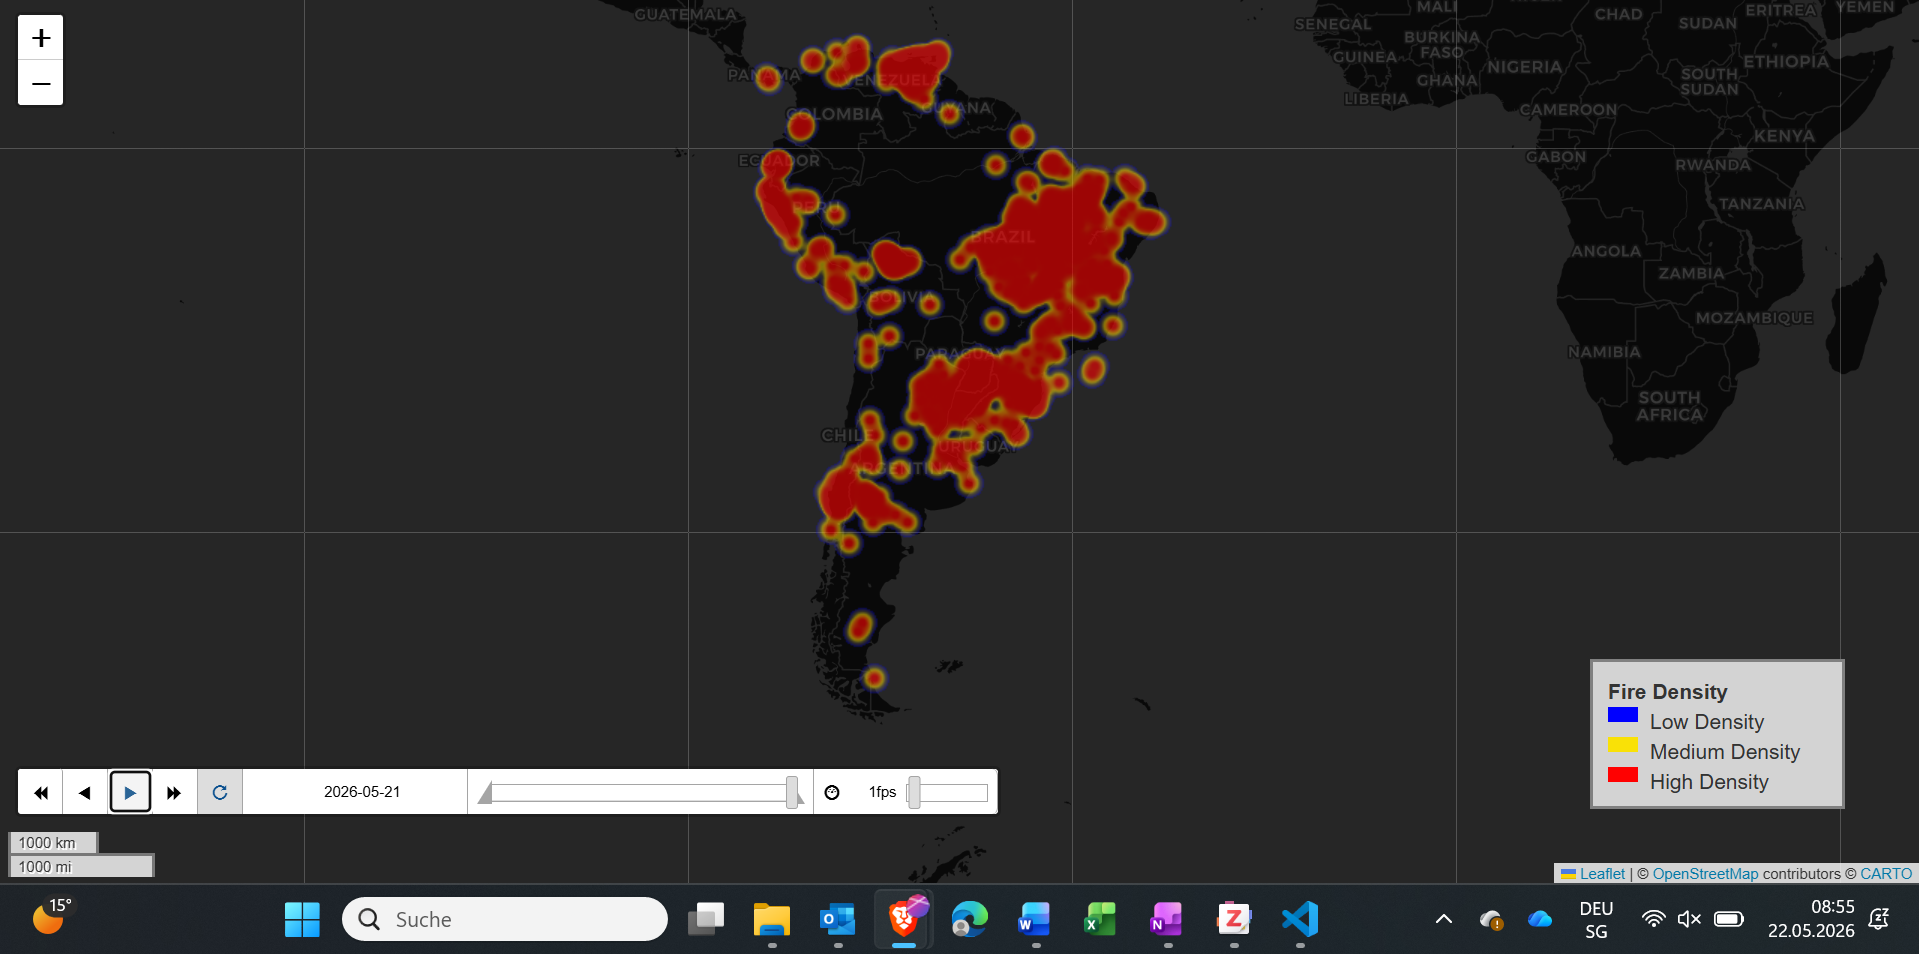

#### **Results**

*1. How has the fire distribution in South America changed over the past five days?*

*2. Are there any fire distribution patterns identifiable?*

When looking at the time animated heatmap, five main fire clusters are always visible over the chosen time range. They are located in Venezuela, eastern Brazil, Peru and Ecuador, Southeastern Paraguay and in the middle of Chile. Interesting is that the fires tend to be more at the edge of the continent rather than in the middle. This is especially true for the northern part. Over-all, the fire distribution does not vary strongly in the analysed time range. Reasons for this could be stable weather con-ditions, prevailing terrain features and similar fuel availability. Furthermore, the limited duration of five days may not allow to sufficiently capture large-scale variations in wildfires. 

